In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [6]:
from google.colab import files
uploaded = files.upload()

Saving heart.csv to heart.csv


In [7]:
import io
df = pd.read_csv(io.BytesIO(uploaded['heart.csv']))

In [8]:
X = df.drop('target', axis=1)

In [9]:
y = df['target']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

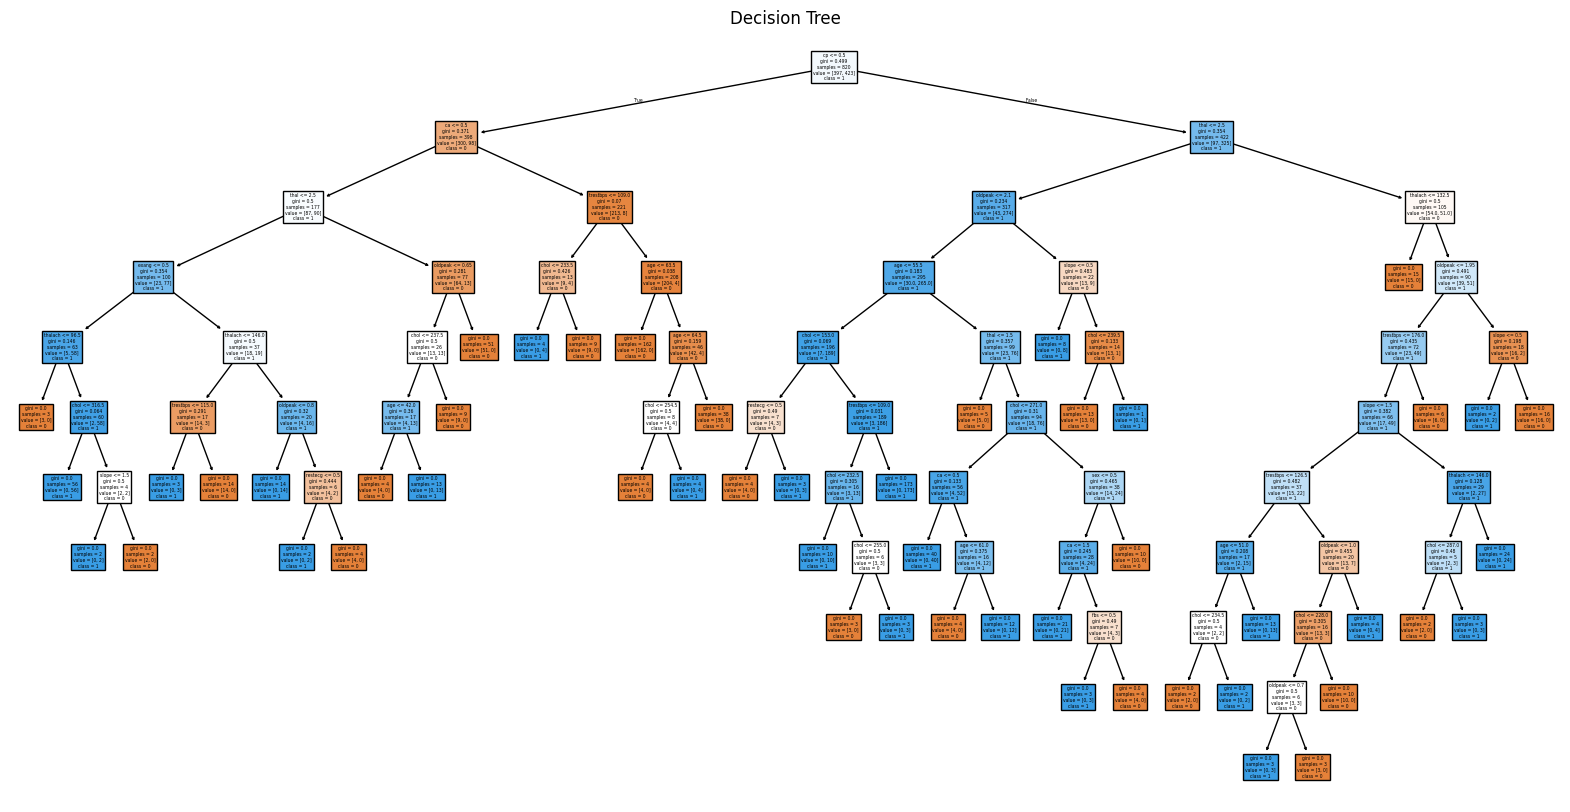

In [12]:
plt.figure(figsize=(20,10))
plot_tree(dt, filled=True, feature_names=X.columns, class_names=['0','1'])
plt.title("Decision Tree")
plt.show()


In [13]:
dt_limited = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_limited.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [14]:
train_acc = dt_limited.score(X_train, y_train)
test_acc = dt_limited.score(X_test, y_test)
print(f"Decision Tree Accuracy (Train): {train_acc:.2f}")
print(f"Decision Tree Accuracy (Test): {test_acc:.2f}")

Decision Tree Accuracy (Train): 0.85
Decision Tree Accuracy (Test): 0.78


In [15]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [16]:
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest Accuracy: {rf_acc:.2f}")

Random Forest Accuracy: 0.99


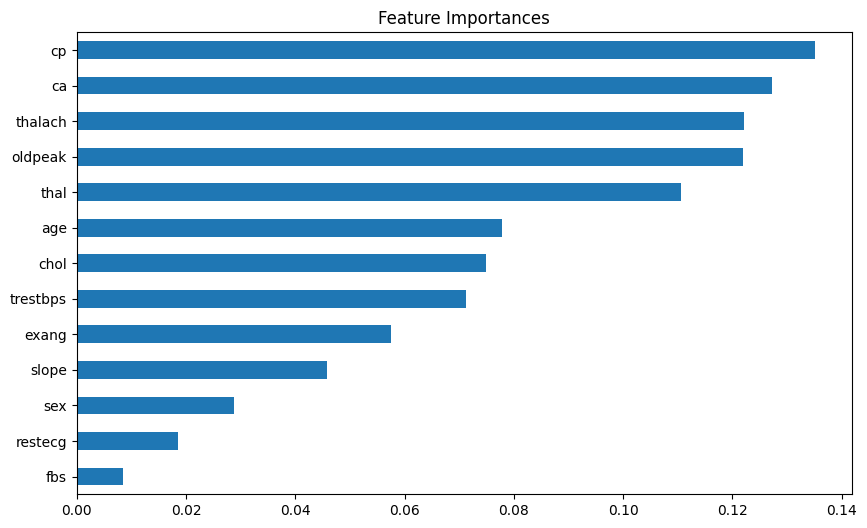

In [17]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10,6), title="Feature Importances")
plt.show()

In [18]:
dt_cv_scores = cross_val_score(dt_limited, X, y, cv=5)
rf_cv_scores = cross_val_score(rf, X, y, cv=5)

In [19]:
print(f"Decision Tree CV Accuracy: {dt_cv_scores.mean():.2f}")
print(f"Random Forest CV Accuracy: {rf_cv_scores.mean():.2f}")

Decision Tree CV Accuracy: 0.83
Random Forest CV Accuracy: 1.00
